# Example 4: SISO Plant and DMC Controller

This example demonstrates the construction and simulation of a closed-loop control system comprising an artificial SISO plant and a DMC controller. A plant model is defined, a DMC controller is configured, and the closed-loop system response to multiple reference trajectories is simulated. The DMC controller is shown to be capable of tracking various trajectory shapes with decent quality.

## Imports

The required packages are: `Akson` for the core functionality, `torch` for defining state-space system matrices, and `matplotlib` for plotting.

In [1]:
import akson
import torch
import matplotlib.pyplot as plt

## Defining the System Dynamics

An artificial toy plant is used for this example. The LTI state-space system matrices are defined as `torch` tensors:

In [2]:
A = torch.tensor([
    [-0.03333, 0.06667],
    [-0.08, -0.4]
], dtype=torch.float64)
B = torch.tensor([
    [0.],
    [0.2]
], dtype=torch.float64)
C = torch.tensor([[1., 0.]], dtype=torch.float64)
D = torch.tensor([[0.]], dtype=torch.float64)

State-space dynamics are constructed from these matrices using the `from_linear` static method:

In [3]:
system_dynamics = akson.StateSpaceDynamics.from_linear(A, B, C, D)

## Time constant

A single time constant is chosen for computing the plant discrete step response and the simulation step. This is required for temporal consistency between the DMC controller, which uses the discrete step response as a plant model, and the continuous plant model in simulation:

In [4]:
dt = 5.

## Calculating the Discrete Step Response for DMC Controller

The discrete step response is computed over a duration of $125$ time units with the previously defined time step:

In [5]:
t_step, y_step = system_dynamics.discrete_step_response(duration=125., dt=dt)

The discrete step response is plotted below (`extended_t` is required for `stairs` to work properly):

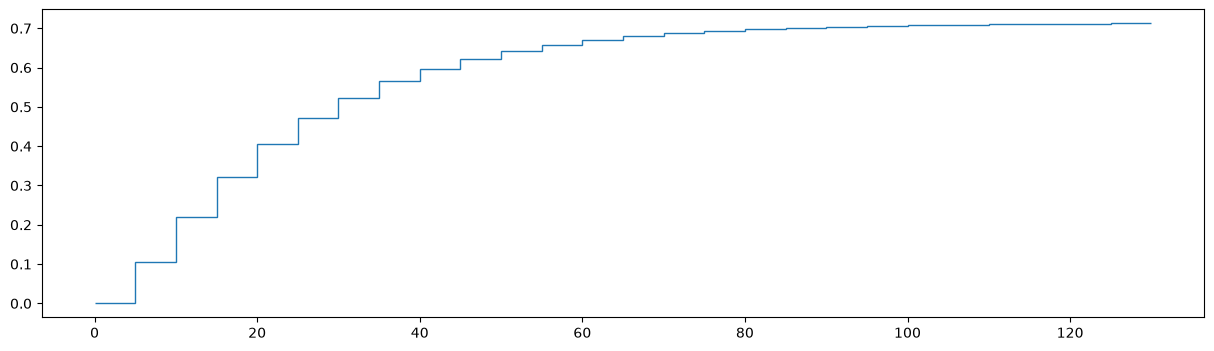

In [6]:
plt.figure(figsize=(15, 4))
extended_t = torch.cat((t_step, 2*t_step[-1:len(t_step)]-t_step[-2:-1]), dim=0)
plt.stairs(y_step[:, 0, 0], extended_t, baseline=None)
plt.show()

## DMC Controller Setup

The DMC controller is configured with a prediction horizon of $N=30$, a control horizon of $N_u=16$, and a regularisation factor of $0.02$. The operating point is taken from the system dynamics:

In [7]:
dmc_config = akson.DMCRegulatorConfiguration(
    step_response=y_step,
    N=30, Nu=16,
    regularisation=0.02,
    operating_point=system_dynamics.operating_point
)
dmc_state = akson.DMCRegulatorState.initial_state_for(dmc_config)

## Closed Loop System Setup

The closed-loop system combines the plant dynamics, the DMC controller configuration, and the controller state:

In [8]:
dmc_closed_system = akson.DMCRegulatorClosedSystem(
    plant_dynamics=system_dynamics, regulator_configuration=dmc_config, regulator_state=dmc_state
)

## Simulations of the Closed Loop System with Plant and Controller

### Simulation 1: Piecewise-Constant Reference Trajectory

The simulation is run over a duration of $200$ time units. A piecewise-constant reference trajectory is defined, consisting of an initial setpoint of $0$ for the first $10$ steps followed by a setpoint of $3$ for the remaining $30$ steps. A substep count of $10$ is used to improve output resolution:

In [9]:
simulation_length = 200
reference_trajectory = torch.tensor([[0.]]*10 +  [[3.]]*30)

t_history, y_history, u_history = dmc_closed_system.simulate(
    r_traj=reference_trajectory,
    duration=simulation_length,
    dt=dt, num_substeps=10,  # Fine resolution
)

/home/antoni/Documents/PRACA/akson/src/akson/_dmc_common.py:270: RuntimeWarning: RKF45: integration completed with 30 rejected and 11 accepted steps; consider relaxing tolerances or using an implicit solver for stiff problems
  t_sub, x_sub = solver.solve(traced_ode_fn, t_span, y0)


The system output is plotted alongside the reference trajectory below:

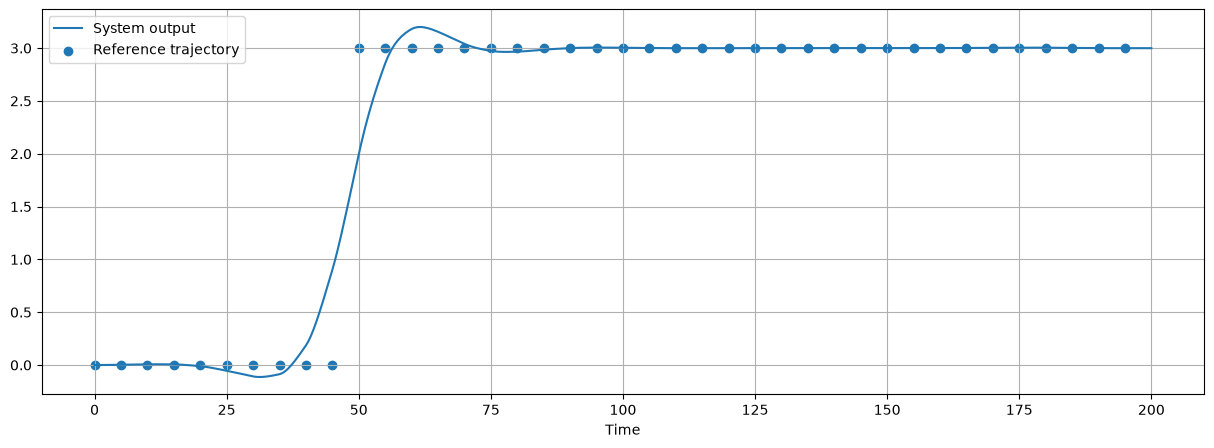

In [10]:
plt.figure(figsize=(15, 5))
plt.plot(t_history, y_history[:, 0])
plt.scatter(torch.arange(reference_trajectory.shape[0])*dt, reference_trajectory[:, 0])
plt.legend(('System output', 'Reference trajectory'))
plt.grid()
plt.xlabel("Time")
plt.show()

The control signal generated by the DMC controller is plotted below:

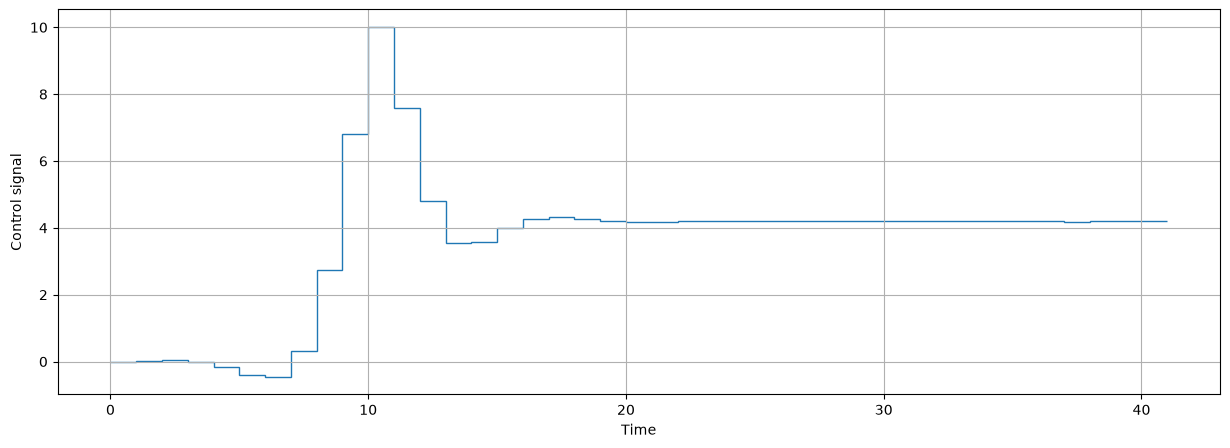

In [11]:
plt.figure(figsize=(15,5))
plt.stairs(u_history[:, 0], range(u_history.shape[0]+1), baseline=None)
plt.grid()
plt.xlabel("Time")
plt.ylabel("Control signal")
plt.show()

### Simulation 2: Sinusoidal Reference Trajectory

The system state is reset before the second simulation:

In [12]:
dmc_closed_system.reset()

A sinusoidal reference trajectory is defined and the simulation is run over a duration of $200$ time units:

In [13]:
simulation_length = 200
reference_trajectory = torch.sin(torch.arange(200/5+1)/2.).unsqueeze(dim=1)

t_history, y_history, u_history = dmc_closed_system.simulate(
    r_traj=reference_trajectory,
    duration=simulation_length,
    dt=dt, num_substeps=10,  # Fine resolution
)

/home/antoni/Documents/PRACA/akson/src/akson/_dmc_common.py:270: RuntimeWarning: RKF45: 20 consecutive rejected steps at x=1.450e2, step=3.058e-1; problem may be stiff
  t_sub, x_sub = solver.solve(traced_ode_fn, t_span, y0)
/home/antoni/Documents/PRACA/akson/src/akson/_dmc_common.py:270: RuntimeWarning: RKF45: integration completed with 24 rejected and 11 accepted steps; consider relaxing tolerances or using an implicit solver for stiff problems
  t_sub, x_sub = solver.solve(traced_ode_fn, t_span, y0)


The system output is plotted alongside the reference trajectory below:

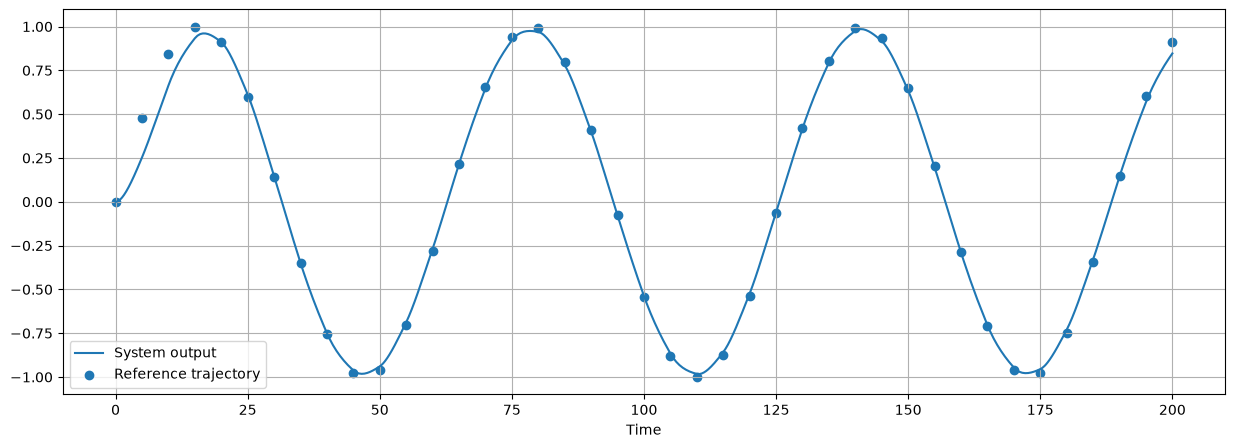

In [14]:
plt.figure(figsize=(15, 5))
plt.plot(t_history, y_history[:, 0])
plt.scatter(torch.arange(reference_trajectory.shape[0])*dt, reference_trajectory[:, 0])
plt.legend(('System output', 'Reference trajectory'))
plt.grid()
plt.xlabel("Time")
plt.show()

The control signal generated by the DMC controller is plotted below:

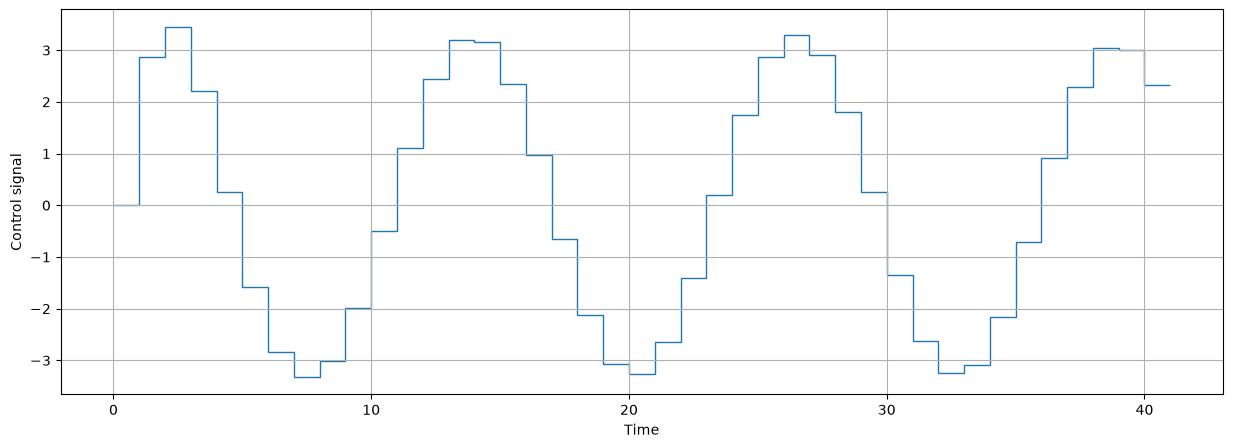

In [15]:
plt.figure(figsize=(15,5))
plt.stairs(u_history[:, 0], range(u_history.shape[0]+1), baseline=None)
plt.grid()
plt.xlabel("Time")
plt.ylabel("Control signal")
plt.show()

### Simulation 3: Triangular Reference Trajectory

The system state is reset before the third simulation:

In [16]:
dmc_closed_system.reset()

A triangular reference trajectory is defined:

In [17]:
def triangles(t):
    return ((t % 100) / 100.)*(t % 100 < 50) + \
           (torch.abs(-t % 100) / 100.)*(t % 100 >= 50)
reference_trajectory = triangles(torch.arange(200/5.+1)*5.).unsqueeze(dim=1)

The simulation is run over a duration of $200$ time units:

In [18]:
simulation_length = 200
t_history, y_history, u_history = dmc_closed_system.simulate(
    r_traj=reference_trajectory,
    duration=simulation_length,
    dt=dt, num_substeps=10,  # Fine resolution
)

The system output is plotted alongside the reference trajectory below:

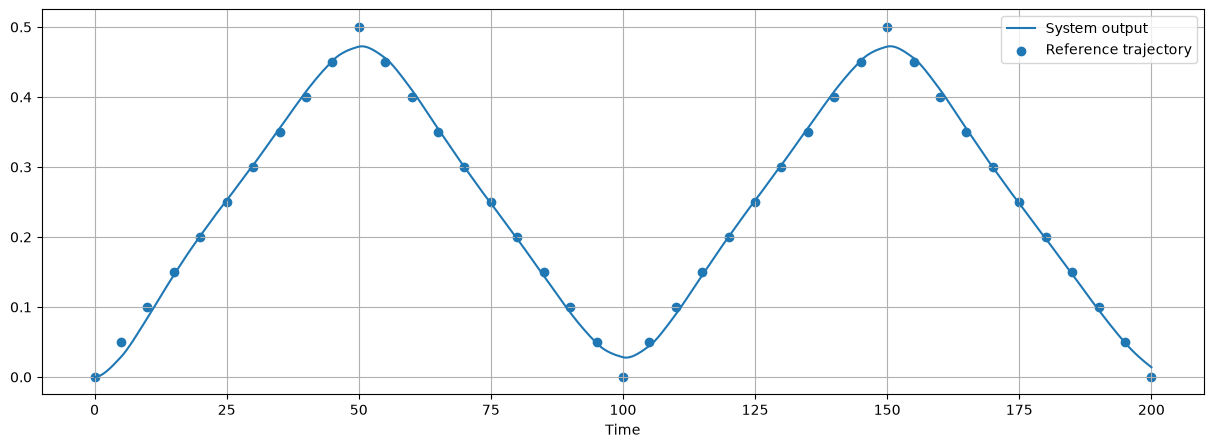

In [19]:
plt.figure(figsize=(15, 5))
plt.plot(t_history, y_history[:, 0])
plt.scatter(torch.arange(reference_trajectory.shape[0])*dt, reference_trajectory[:, 0])
plt.legend(('System output', 'Reference trajectory'))
plt.grid()
plt.xlabel("Time")
plt.show()

The control signal generated by the DMC controller is plotted below:

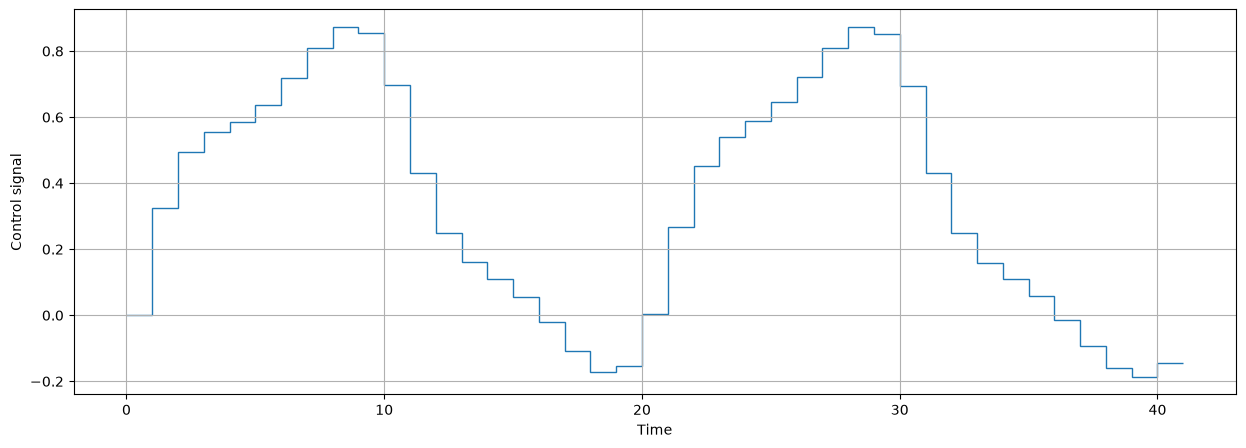

In [20]:
plt.figure(figsize=(15,5))
plt.stairs(u_history[:, 0], range(u_history.shape[0]+1), baseline=None)
plt.grid()
plt.xlabel("Time")
plt.ylabel("Control signal")
plt.show()